In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/tharmmm/Documents/store_sale_project/store-sales-time-series-forecasting/train.csv")
df.head(20)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [40]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [10]:
df.shape

(3000888, 6)

### Check null value

In [50]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

### Number of unique store

In [17]:
print(np.sort(df["store_nbr"].unique()))
print(f"number of stores : {len(df['store_nbr'].unique())}")

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54]
number of stores : 54


### The number of stuff in store

In [35]:
print(df[df["store_nbr"] == 1]["family"].unique())
print(f"The number of unique family in one store : {len(df[df['store_nbr'] == 1]['family'].unique())}")

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']
The number of unique family in one store : 33


In [41]:
for store, count in df.groupby("store_nbr")["family"].nunique().items():
    print(f"The number of unique family in store {store} : {count}")


The number of unique family in store 1 : 33
The number of unique family in store 2 : 33
The number of unique family in store 3 : 33
The number of unique family in store 4 : 33
The number of unique family in store 5 : 33
The number of unique family in store 6 : 33
The number of unique family in store 7 : 33
The number of unique family in store 8 : 33
The number of unique family in store 9 : 33
The number of unique family in store 10 : 33
The number of unique family in store 11 : 33
The number of unique family in store 12 : 33
The number of unique family in store 13 : 33
The number of unique family in store 14 : 33
The number of unique family in store 15 : 33
The number of unique family in store 16 : 33
The number of unique family in store 17 : 33
The number of unique family in store 18 : 33
The number of unique family in store 19 : 33
The number of unique family in store 20 : 33
The number of unique family in store 21 : 33
The number of unique family in store 22 : 33
The number of uniqu

In [45]:
df.groupby(["store_nbr","family"])["sales"].sum()

store_nbr  family                    
1          AUTOMOTIVE                    5.475000e+03
           BABY CARE                     0.000000e+00
           BEAUTY                        4.056000e+03
           BEVERAGES                     2.673769e+06
           BOOKS                         2.110000e+02
                                             ...     
54         POULTRY                       8.888981e+04
           PREPARED FOODS                1.030900e+05
           PRODUCE                       5.961803e+05
           SCHOOL AND OFFICE SUPPLIES    1.023000e+03
           SEAFOOD                       2.938000e+03
Name: sales, Length: 1782, dtype: float64

### Range of Date

In [47]:
print(f"Number of days : {df['date'].nunique()}")
print(f"Date range : {df['date'].min()} to {df['date'].max()}")


Number of days : 1684
Date range : 2013-01-01 to 2017-08-15


In [48]:
df.groupby("store_nbr")["date"].agg(["min", "max", "nunique"])

,min,max,nunique
store_nbr,,,
1,2013-01-01,2017-08-15,1684
2,2013-01-01,2017-08-15,1684
3,2013-01-01,2017-08-15,1684
4,2013-01-01,2017-08-15,1684
5,2013-01-01,2017-08-15,1684
6,2013-01-01,2017-08-15,1684
7,2013-01-01,2017-08-15,1684
8,2013-01-01,2017-08-15,1684
9,2013-01-01,2017-08-15,1684


### Daily Aggregated Distribution

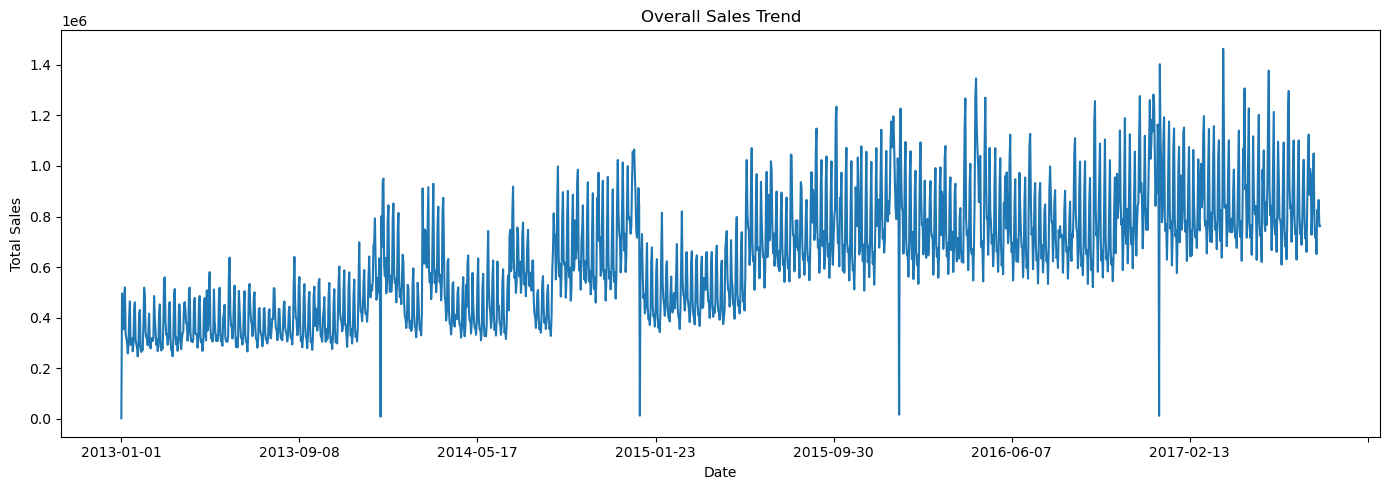

In [54]:
df.groupby("date")["sales"].sum().plot(figsize=(14, 5), title="Overall Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

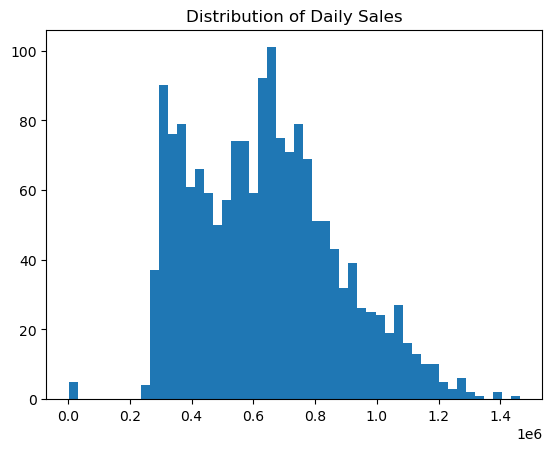

In [49]:
daily = df.groupby("date")["sales"].sum().reset_index()
plt.hist(daily["sales"], bins=50)
plt.title("Distribution of Daily Sales")
plt.show()

(array([2.885961e+06, 7.864300e+04, 2.147200e+04, 8.729000e+03,
        3.481000e+03, 1.696000e+03, 6.090000e+02, 1.850000e+02,
        6.700000e+01, 1.400000e+01, 6.000000e+00, 5.000000e+00,
        5.000000e+00, 2.000000e+00, 2.000000e+00, 2.000000e+00,
        1.000000e+00, 0.000000e+00, 2.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 1.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 2.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([     0.  ,   2494.34,   4988.68,   7483.02,   9977.36,  12471.7 ,
         14966.04,  17460.38,  19954.72,  22449.06,  24943.4 ,  27437.74,
         29932.08,  32426.42,  34920.76,  3741

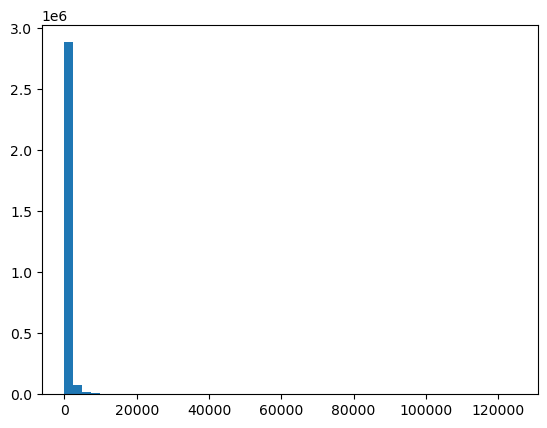

In [51]:
plt.hist(df['sales'], bins = 50)

The raw sales distribution is heavily right-skewed with extreme outliers and many near-zero values

In [53]:
print(f"Percentage of zero sales:: {((df['sales'] == 0).mean()*100):.2f} %")

Percentage of zero sales:: 31.30 %


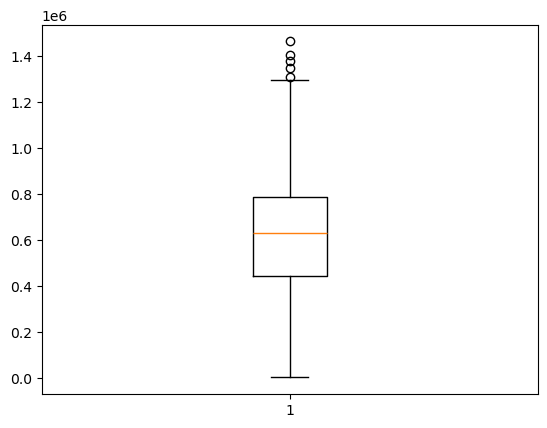

In [52]:
plt.boxplot(daily["sales"])
plt.show()

### Weekly Seasonality

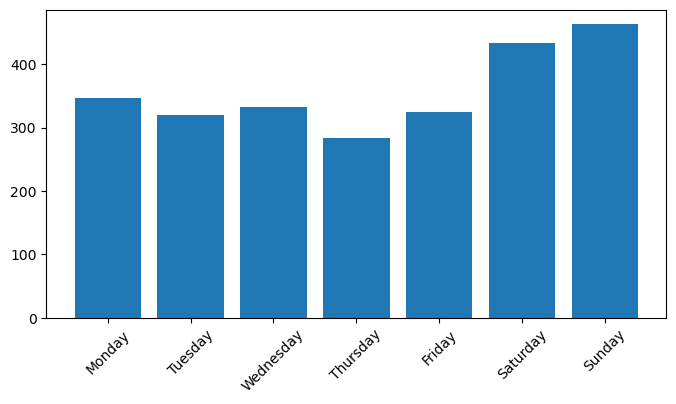

   day_of_week   day_name       sales
0            0     Monday  346.544732
1            1    Tuesday  319.823843
2            2  Wednesday  332.909401
3            3   Thursday  283.540517
4            4     Friday  325.238138
5            5   Saturday  433.336472
6            6     Sunday  463.085366


In [22]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['day_name'] = df['date'].dt.day_name()

day_sales = df.groupby(['day_of_week', 'day_name'])['sales'].mean().reset_index()

day_sales = day_sales.sort_values('day_of_week')
plt.figure(figsize=(8,4))
plt.bar(day_sales['day_name'], day_sales['sales'])
plt.xticks(rotation=45)
plt.show()

print(day_sales)


The bar chart shows that sales peak on Saturday and Sunday.

### Monthly Pattern

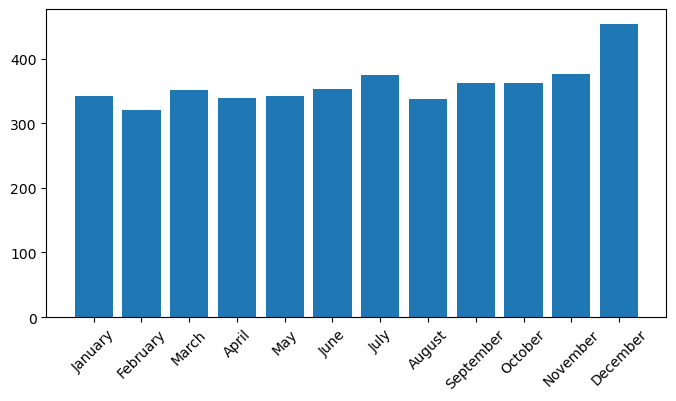

In [25]:
df["month"] = df["date"].dt.month
df['month_name'] = df['date'].dt.month_name()

month_sales = df.groupby(['month', 'month_name'])['sales'].mean().reset_index()
month_sales = month_sales.sort_values('month')

plt.figure(figsize=(8,4))
plt.bar(month_sales['month_name'], month_sales['sales'])
plt.xticks(rotation=45)
plt.show()

The bar chart shows that sales peak on December.

### Promotion Effect

onpromotion columnn is the number of product in that family are on promotion

In [26]:
df.groupby("onpromotion")["sales"].mean().head(20)

onpromotion
0      158.246681
1      467.556532
2      662.925632
3      871.408092
4      969.916135
5     1010.659835
6     1022.854287
7     1022.567058
8     1174.757003
9     1258.733993
10    1303.985479
11    1264.356349
12    1218.066159
13    1322.552007
14    1376.628033
15    1446.988239
16    1498.333841
17    1559.588638
18    1526.680412
19    1619.292366
Name: sales, dtype: float64

In [30]:
df.groupby(["family", "onpromotion"])["sales"].mean()

family      onpromotion
AUTOMOTIVE  0               5.853087
            1              12.271947
            2              13.480392
            3              15.923954
            4              18.936170
                             ...    
SEAFOOD     3              28.202830
            4              22.856937
            5              38.068377
            6              67.198554
            7              96.299518
Name: sales, Length: 1688, dtype: float64

In [31]:
df[["sales", "onpromotion"]].corr()

,sales,onpromotion
sales,1.000000,0.427923
onpromotion,0.427923,1.000000


<Axes: xlabel='onpromotion', ylabel='sales'>

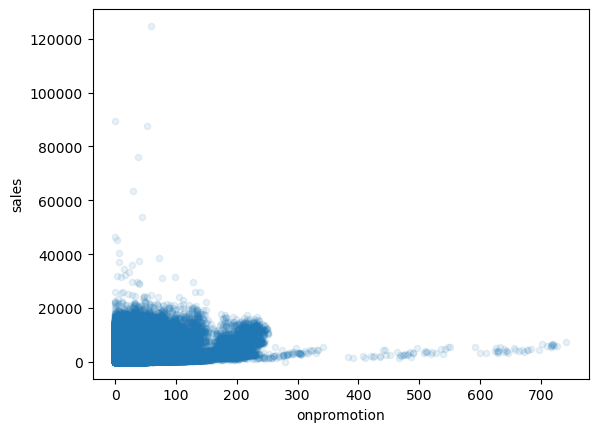

In [32]:
df.plot.scatter(x="onpromotion", y="sales", alpha=0.1)

choose top 5 family that have the highest sale

In [34]:
top_families = (
    df.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = df[df["family"].isin(top_families)]

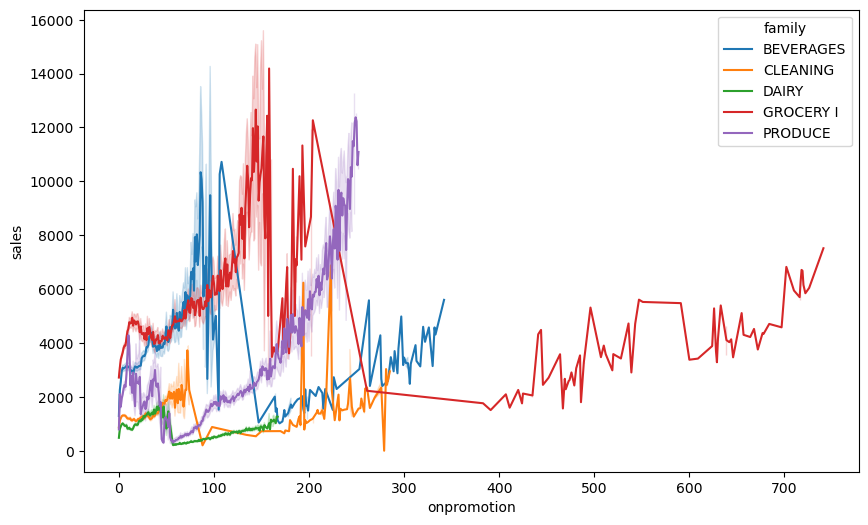

In [35]:
plt.figure(figsize=(10,6))
sns.lineplot(data=filtered,
             x="onpromotion",
             y="sales",
             hue="family",
             estimator="mean")
plt.show()

In [36]:
family_corr = (
    df.groupby("family")
      .apply(lambda x: x[["sales","onpromotion"]].corr().iloc[0,1])
)

/var/folders/6w/4xp185f12bs781fd1mwl2qvh0000gn/T/ipykernel_8371/1669827332.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[["sales","onpromotion"]].corr().iloc[0,1])


In [46]:
df.groupby("family")[["sales","onpromotion"]].corr()

sales  onpromotion
family                                                       
AUTOMOTIVE                 sales        1.000000     0.209826
                           onpromotion  0.209826     1.000000
BABY CARE                  sales        1.000000     0.054954
                           onpromotion  0.054954     1.000000
BEAUTY                     sales        1.000000     0.342411
...                                          ...          ...
PRODUCE                    onpromotion  0.356896     1.000000
SCHOOL AND OFFICE SUPPLIES sales        1.000000     0.669793
                           onpromotion  0.669793     1.000000
SEAFOOD                    sales        1.000000     0.289401
                           onpromotion  0.289401     1.000000

[66 rows x 2 columns]

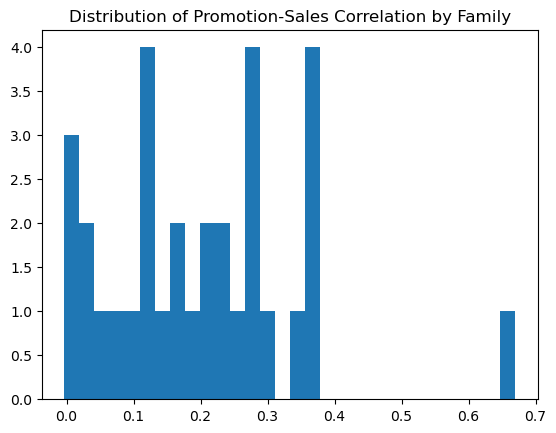

In [37]:
plt.hist(family_corr, bins=30)
plt.title("Distribution of Promotion-Sales Correlation by Family")
plt.show()

y-axis is number of family 

Promotion generally has a positive impact on sales across product families, although the strength of the relationship varies, with most families showing weak-to-moderate sensitivity.

In [47]:
print("top 5 family that got the most effect from promotion")
family_corr.sort_values(ascending=False).head()

top 5 family that got the most effect from promotion


family
SCHOOL AND OFFICE SUPPLIES    0.669793
BEVERAGES                     0.372682
HOME CARE                     0.369643
HOME AND KITCHEN II           0.362344
PRODUCE                       0.356896
dtype: float64